[SUCCESS] Methodology Flowchart generated without overlaps.
 -> PDF: .\graphics\1.pdf
 -> PNG: .\graphics\methodology_flowchart_fixed.png


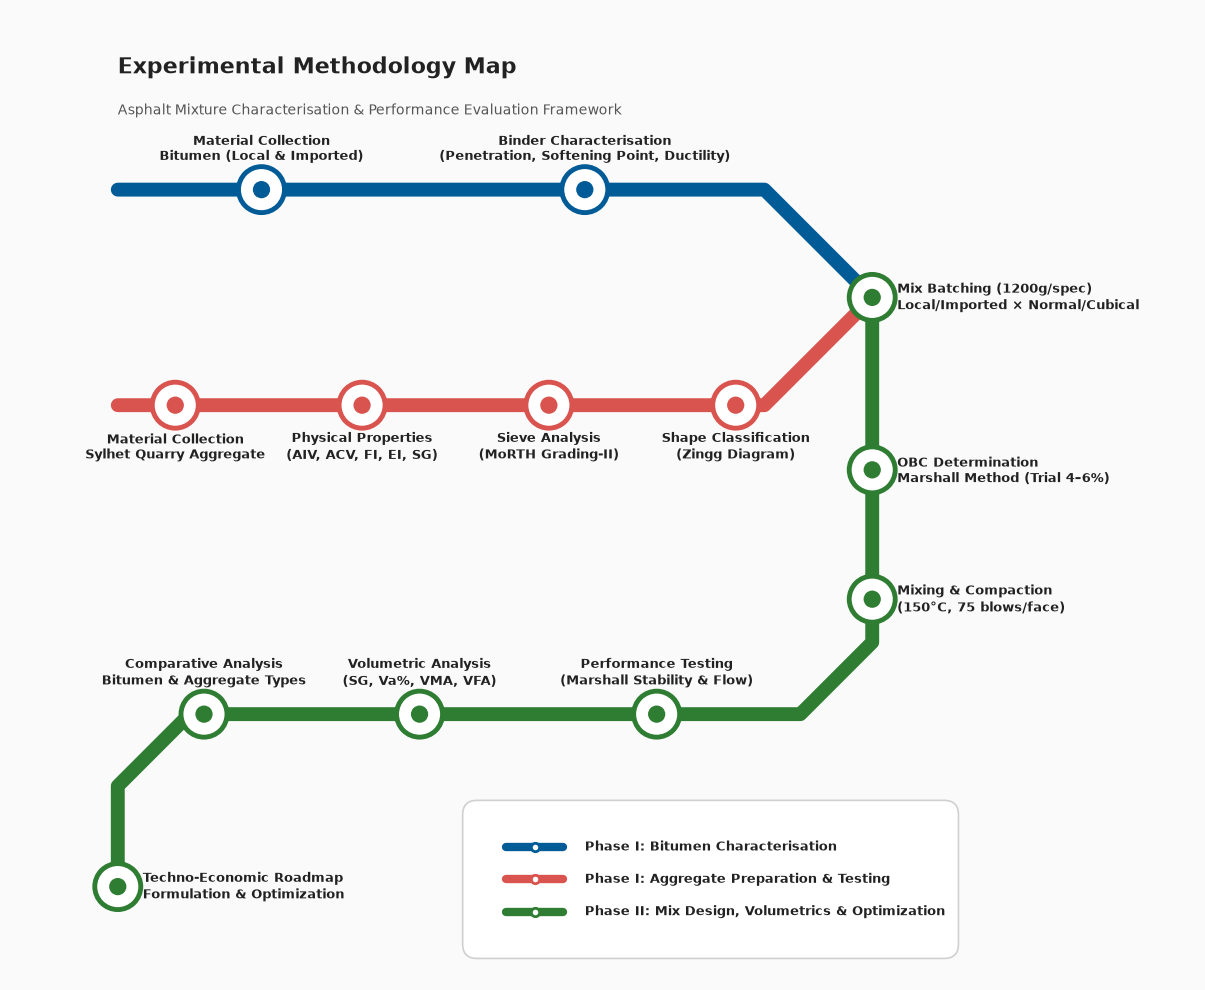

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

# Set directory paths
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'
GRAPHICS_DIR = os.path.join(BASE_DIR, 'graphics')
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# Colors - Premium Elsevier Quality Palette
COLORS = {
    'bitumen_line': '#005b96',     # Deep Professional Blue
    'aggregate_line': '#d9534f',   # Muted Rust/Orange
    'mix_line': '#2e7d32',         # Emerald Green
    'station_fill': '#ffffff',     # Pure White
    'text': '#222222',             # Dark Charcoal for high contrast
    'text_sub': '#555555',         # Subtitle Gray
    'bg': '#fafafa',               # Subtle off-white background
    'legend_bg': '#ffffff'
}

def create_subway_path(ax, points, color, linewidth=10):
    """Draws a thick subway line connecting points with smooth joins."""
    x, y = zip(*points)
    ax.plot(x, y, color=color, linewidth=linewidth, 
            solid_capstyle='round', solid_joinstyle='round', zorder=2)

def draw_station(ax, x, y, color, label, label_pos='top', align=None):
    """Draws a dual-ring subway station marker and offset label."""
    # Outer circle
    circle = patches.Circle((x, y), radius=0.32, 
                            facecolor=COLORS['station_fill'], 
                            edgecolor=color, 
                            linewidth=3.5, 
                            zorder=4)
    ax.add_patch(circle)
    
    # Inner dot
    inner_circle = patches.Circle((x, y), radius=0.12, 
                                  facecolor=color, 
                                  zorder=5)
    ax.add_patch(inner_circle)
    
    # Label positioning and alignment
    offset = 18
    if label_pos == 'top':
        xytext = (0, offset)
        va = 'bottom'
        ha = align or 'center'
    elif label_pos == 'bottom':
        xytext = (0, -offset)
        va = 'top'
        ha = align or 'center'
    elif label_pos == 'right':
        xytext = (offset, 0)
        va = 'center'
        ha = align or 'left'
    elif label_pos == 'left':
        xytext = (-offset, 0)
        va = 'center'
        ha = align or 'right'
    elif label_pos == 'top_right':
        xytext = (offset, offset)
        va = 'bottom'
        ha = align or 'left'
    else:
        xytext = (0, offset)
        va = 'bottom'
        ha = 'center'
    
    font = FontProperties(family='sans-serif', weight='bold', size=9.5)
    
    ax.annotate(label, xy=(x, y), xytext=xytext, textcoords='offset points',
                ha=ha, va=va, color=COLORS['text'], fontproperties=font, 
                linespacing=1.25, zorder=6)

def generate_subway_methodology():
    """Generates the methodology flowchart without visual overlaps."""
    
    fig, ax = plt.subplots(figsize=(15, 10), facecolor=COLORS['bg'])
    ax.set_aspect('equal')
    ax.axis('off')
    
    # --- 1. Define Line Paths (45-degree clean transitions) ---
    bitumen_path = [
        (1.0, 9.5),
        (10.0, 9.5),
        (11.5, 8.0)
    ]
    
    aggregate_path = [
        (1.0, 6.5),
        (10.0, 6.5),
        (11.5, 8.0)
    ]
    
    mix_path = [
        (11.5, 8.0),
        (11.5, 3.2),
        (10.5, 2.2),
        (2.0, 2.2),
        (1.0, 1.2),
        (1.0, -0.2)
    ]
    
    # --- 2. Draw Subway Lines ---
    create_subway_path(ax, bitumen_path, COLORS['bitumen_line'])
    create_subway_path(ax, aggregate_path, COLORS['aggregate_line'])
    create_subway_path(ax, mix_path, COLORS['mix_line'])
    
    # --- 3. Stations & Labels ---
    
    # Bitumen Line (Top Track)
    draw_station(ax, 3.0, 9.5, COLORS['bitumen_line'], 
                 "Material Collection\nBitumen (Local & Imported)", 'top')
    draw_station(ax, 7.5, 9.5, COLORS['bitumen_line'], 
                 "Binder Characterisation\n(Penetration, Softening Point, Ductility)", 'top')
                 
    # Aggregate Line (Middle Track)
    draw_station(ax, 1.8, 6.5, COLORS['aggregate_line'], 
                 "Material Collection\nSylhet Quarry Aggregate", 'bottom')
    draw_station(ax, 4.4, 6.5, COLORS['aggregate_line'], 
                 "Physical Properties\n(AIV, ACV, FI, EI, SG)", 'bottom')
    draw_station(ax, 7.0, 6.5, COLORS['aggregate_line'], 
                 "Sieve Analysis\n(MoRTH Grading-II)", 'bottom')
    draw_station(ax, 9.6, 6.5, COLORS['aggregate_line'], 
                 "Shape Classification\n(Zingg Diagram)", 'bottom')
                 
    # Mix Line - Convergence & Vertical Processing
    draw_station(ax, 11.5, 8.0, COLORS['mix_line'], 
                 "Mix Batching (1200g/spec)\nLocal/Imported × Normal/Cubical", 'right')
    draw_station(ax, 11.5, 5.6, COLORS['mix_line'], 
                 "OBC Determination\nMarshall Method (Trial 4–6%)", 'right')
    draw_station(ax, 11.5, 3.8, COLORS['mix_line'], 
                 "Mixing & Compaction\n(150°C, 75 blows/face)", 'right')
                 
    # Mix Line - Horizontal Testing & Volumetrics (Bottom Track)
    draw_station(ax, 8.5, 2.2, COLORS['mix_line'], 
                 "Performance Testing\n(Marshall Stability & Flow)", 'top')
    draw_station(ax, 5.2, 2.2, COLORS['mix_line'], 
                 "Volumetric Analysis\n(SG, Va%, VMA, VFA)", 'top')
    draw_station(ax, 2.2, 2.2, COLORS['mix_line'], 
                 "Comparative Analysis\nBitumen & Aggregate Types", 'top')
                 
    # Mix Line - Terminal Optimization Station
    draw_station(ax, 1.0, -0.2, COLORS['mix_line'], 
                 "Techno-Economic Roadmap\nFormulation & Optimization", 'right')
                 
    # --- 4. Titles & Header ---
    font_title = FontProperties(family='sans-serif', weight='bold', size=16)
    font_sub = FontProperties(family='sans-serif', weight='normal', size=10)
    
    ax.text(1.0, 11.2, "Experimental Methodology Map", 
            fontproperties=font_title, color=COLORS['text'], ha='left', va='center')
    ax.text(1.0, 10.6, "Asphalt Mixture Characterisation & Performance Evaluation Framework", 
            fontproperties=font_sub, color=COLORS['text_sub'], ha='left', va='center')
            
    # --- 5. Legend (Relocated to clear bottom-right quadrant) ---
    font_legend = FontProperties(family='sans-serif', weight='bold', size=9.5)
    
    legend_box = patches.FancyBboxPatch((6.0, -1.0), 6.5, 1.8, 
                                        boxstyle="round,pad=0.2", 
                                        facecolor=COLORS['legend_bg'], 
                                        edgecolor='#d0d0d0', linewidth=1.2, zorder=3)
    ax.add_patch(legend_box)
    
    # Legend Entries
    entries = [
        (COLORS['bitumen_line'], "Phase I: Bitumen Characterisation", 0.35),
        (COLORS['aggregate_line'], "Phase I: Aggregate Preparation & Testing", -0.10),
        (COLORS['mix_line'], "Phase II: Mix Design, Volumetrics & Optimization", -0.55)
    ]
    
    for color, text, y_pos in entries:
        ax.plot([6.4, 7.2], [y_pos, y_pos], color=color, lw=6, solid_capstyle='round', zorder=4)
        ax.plot(6.8, y_pos, marker='o', markersize=6, markerfacecolor='white', 
                markeredgecolor=color, markeredgewidth=2, zorder=5)
        ax.text(7.5, y_pos, text, va='center', fontproperties=font_legend, color=COLORS['text'], zorder=4)
    
    # Canvas limits with balanced margins
    ax.set_xlim(-0.5, 16.0)
    ax.set_ylim(-1.5, 12.0)
    
    plt.tight_layout()
    output_pdf = os.path.join(GRAPHICS_DIR, '1.pdf')
    output_png = os.path.join(GRAPHICS_DIR, 'methodology_flowchart_fixed.png')
    
    #plt.savefig(output_pdf, format='pdf', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    #plt.savefig(output_png, format='png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    print(f"[SUCCESS] Methodology Flowchart generated without overlaps.")
    print(f" -> PDF: {output_pdf}")
    print(f" -> PNG: {output_png}")

if __name__ == "__main__":
    generate_subway_methodology()

[SUCCESS] Methodology Flowchart generated without overlaps.
 -> PDF: .\graphics\1.pdf
 -> PNG: .\graphics\methodology_flowchart_fixed.png
 -> Font used: Arial


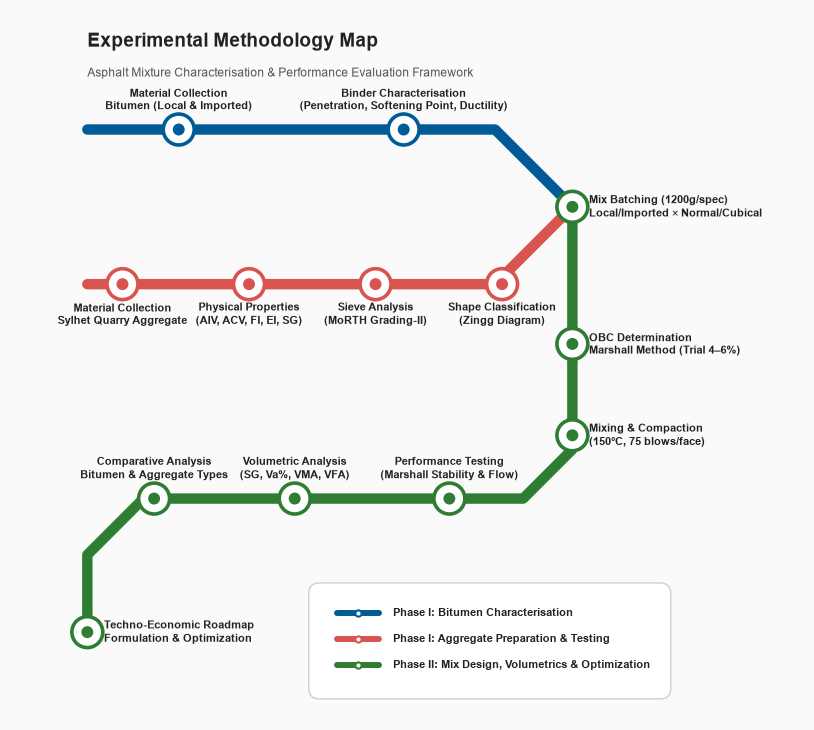

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties, fontManager

# Set directory paths
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'
GRAPHICS_DIR = os.path.join(BASE_DIR, 'graphics')
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# Pick the best available font on this system, with safe fallbacks
_available = {f.name for f in fontManager.ttflist}
_PREFERRED_FONTS = ['Liberation Sans', 'Arial', 'Helvetica', 'DejaVu Sans']
FONT_FAMILY = next((f for f in _PREFERRED_FONTS if f in _available), 'sans-serif')

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.unicode_minus'] = False

# Colors - Premium Elsevier Quality Palette
COLORS = {
    'bitumen_line': '#005b96',     # Deep Professional Blue
    'aggregate_line': '#d9534f',   # Muted Rust/Orange
    'mix_line': '#2e7d32',         # Emerald Green
    'station_fill': '#ffffff',     # Pure White
    'text': '#222222',             # Dark Charcoal for high contrast
    'text_sub': '#555555',         # Subtitle Gray
    'bg': '#fafafa',               # Subtle off-white background
    'legend_bg': '#ffffff'
}


def create_subway_path(ax, points, color, linewidth=7.5):
    """Draws a thick subway line connecting points with smooth joins."""
    x, y = zip(*points)
    ax.plot(x, y, color=color, linewidth=linewidth,
            solid_capstyle='round', solid_joinstyle='round', zorder=2)


def draw_station(ax, x, y, color, label, label_pos='top', align=None, fontsize=7.6):
    """Draws a dual-ring subway station marker and offset label."""
    # Outer circle
    circle = patches.Circle((x, y), radius=0.22,
                             facecolor=COLORS['station_fill'],
                             edgecolor=color,
                             linewidth=2.6,
                             zorder=4)
    ax.add_patch(circle)

    # Inner dot
    inner_circle = patches.Circle((x, y), radius=0.085,
                                   facecolor=color,
                                   zorder=5)
    ax.add_patch(inner_circle)

    # Label positioning and alignment
    offset = 12
    if label_pos == 'top':
        xytext = (0, offset)
        va = 'bottom'
        ha = align or 'center'
    elif label_pos == 'bottom':
        xytext = (0, -offset)
        va = 'top'
        ha = align or 'center'
    elif label_pos == 'right':
        xytext = (offset, 0)
        va = 'center'
        ha = align or 'left'
    elif label_pos == 'left':
        xytext = (-offset, 0)
        va = 'center'
        ha = align or 'right'
    elif label_pos == 'top_right':
        xytext = (offset, offset)
        va = 'bottom'
        ha = align or 'left'
    else:
        xytext = (0, offset)
        va = 'bottom'
        ha = 'center'

    font = FontProperties(family=FONT_FAMILY, weight='bold', size=fontsize)

    ax.annotate(label, xy=(x, y), xytext=xytext, textcoords='offset points',
                ha=ha, va=va, color=COLORS['text'], fontproperties=font,
                linespacing=1.35, zorder=6)


def generate_subway_methodology():
    """Generates a compact methodology flowchart without visual overlaps."""

    fig, ax = plt.subplots(figsize=(11, 7.4), facecolor=COLORS['bg'])
    ax.set_aspect('equal')
    ax.axis('off')

    # --- 1. Define Line Paths (compact layout, clean 45-degree transitions) ---
    bitumen_path = [
        (0.8, 7.1),
        (6.6, 7.1),
        (7.7, 6.0)
    ]

    aggregate_path = [
        (0.8, 4.9),
        (6.6, 4.9),
        (7.7, 6.0)
    ]

    mix_path = [
        (7.7, 6.0),
        (7.7, 2.55),
        (7.0, 1.85),
        (1.6, 1.85),
        (0.8, 1.05),
        (0.8, -0.05)
    ]

    # --- 2. Draw Subway Lines ---
    create_subway_path(ax, bitumen_path, COLORS['bitumen_line'])
    create_subway_path(ax, aggregate_path, COLORS['aggregate_line'])
    create_subway_path(ax, mix_path, COLORS['mix_line'])

    # --- 3. Stations & Labels ---

    # Bitumen Line (Top Track)
    draw_station(ax, 2.1, 7.1, COLORS['bitumen_line'],
                 "Material Collection\nBitumen (Local & Imported)", 'top')
    draw_station(ax, 5.3, 7.1, COLORS['bitumen_line'],
                 "Binder Characterisation\n(Penetration, Softening Point, Ductility)", 'top')

    # Aggregate Line (Middle Track)
    draw_station(ax, 1.3, 4.9, COLORS['aggregate_line'],
                 "Material Collection\nSylhet Quarry Aggregate", 'bottom')
    draw_station(ax, 3.1, 4.9, COLORS['aggregate_line'],
                 "Physical Properties\n(AIV, ACV, FI, EI, SG)", 'bottom')
    draw_station(ax, 4.9, 4.9, COLORS['aggregate_line'],
                 "Sieve Analysis\n(MoRTH Grading-II)", 'bottom')
    draw_station(ax, 6.7, 4.9, COLORS['aggregate_line'],
                 "Shape Classification\n(Zingg Diagram)", 'bottom')

    # Mix Line - Convergence & Vertical Processing
    draw_station(ax, 7.7, 6.0, COLORS['mix_line'],
                 "Mix Batching (1200g/spec)\nLocal/Imported \u00d7 Normal/Cubical", 'right')
    draw_station(ax, 7.7, 4.05, COLORS['mix_line'],
                 "OBC Determination\nMarshall Method (Trial 4\u20136%)", 'right')
    draw_station(ax, 7.7, 2.75, COLORS['mix_line'],
                 "Mixing & Compaction\n(150\u00b0C, 75 blows/face)", 'right')

    # Mix Line - Horizontal Testing & Volumetrics (Bottom Track)
    draw_station(ax, 5.95, 1.85, COLORS['mix_line'],
                 "Performance Testing\n(Marshall Stability & Flow)", 'top')
    draw_station(ax, 3.75, 1.85, COLORS['mix_line'],
                 "Volumetric Analysis\n(SG, Va%, VMA, VFA)", 'top')
    draw_station(ax, 1.75, 1.85, COLORS['mix_line'],
                 "Comparative Analysis\nBitumen & Aggregate Types", 'top')

    # Mix Line - Terminal Optimization Station
    draw_station(ax, 0.8, -0.05, COLORS['mix_line'],
                 "Techno-Economic Roadmap\nFormulation & Optimization", 'right')

    # --- 4. Titles & Header ---
    font_title = FontProperties(family=FONT_FAMILY, weight='bold', size=13.5)
    font_sub = FontProperties(family=FONT_FAMILY, weight='normal', size=8.8)

    ax.text(0.8, 8.35, "Experimental Methodology Map",
            fontproperties=font_title, color=COLORS['text'], ha='left', va='center')
    ax.text(0.8, 7.9, "Asphalt Mixture Characterisation & Performance Evaluation Framework",
            fontproperties=font_sub, color=COLORS['text_sub'], ha='left', va='center')

    # --- 5. Legend (compact, bottom-right quadrant) ---
    font_legend = FontProperties(family=FONT_FAMILY, weight='bold', size=7.8)

    legend_box = patches.FancyBboxPatch((4.1, -0.85), 4.85, 1.35,
                                         boxstyle="round,pad=0.15",
                                         facecolor=COLORS['legend_bg'],
                                         edgecolor='#d0d0d0', linewidth=1.0, zorder=3)
    ax.add_patch(legend_box)

    # Legend Entries
    entries = [
        (COLORS['bitumen_line'], "Phase I: Bitumen Characterisation", 0.22),
        (COLORS['aggregate_line'], "Phase I: Aggregate Preparation & Testing", -0.15),
        (COLORS['mix_line'], "Phase II: Mix Design, Volumetrics & Optimization", -0.52)
    ]

    for color, text, y_pos in entries:
        ax.plot([4.35, 4.95], [y_pos, y_pos], color=color, lw=4.3,
                 solid_capstyle='round', zorder=4)
        ax.plot(4.65, y_pos, marker='o', markersize=4.5, markerfacecolor='white',
                 markeredgecolor=color, markeredgewidth=1.5, zorder=5)
        ax.text(5.15, y_pos, text, va='center', fontproperties=font_legend,
                color=COLORS['text'], zorder=4)

    # Canvas limits with tight, balanced margins
    ax.set_xlim(-0.3, 11.0)
    ax.set_ylim(-1.3, 8.8)

    plt.tight_layout()
    output_pdf = os.path.join(GRAPHICS_DIR, '1.pdf')
    output_png = os.path.join(GRAPHICS_DIR, 'methodology_flowchart_fixed.png')

    #plt.savefig(output_pdf, format='pdf', bbox_inches='tight', facecolor=fig.get_facecolor())
    #plt.savefig(output_png, format='png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

    print(f"[SUCCESS] Methodology Flowchart generated without overlaps.")
    print(f" -> PDF: {output_pdf}")
    print(f" -> PNG: {output_png}")
    print(f" -> Font used: {FONT_FAMILY}")


if __name__ == "__main__":
    generate_subway_methodology()

[SUCCESS] Methodology Flowchart generated without overlaps.
 -> PDF: .\graphics\1.pdf
 -> PNG: .\graphics\methodology_flowchart_fixed.png
 -> Font used: Arial


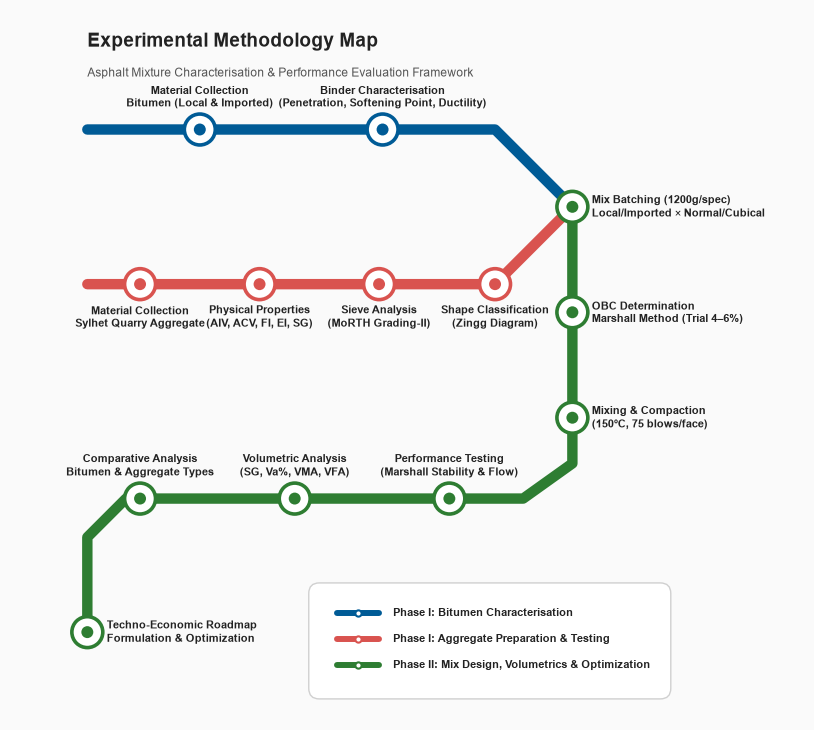

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties, fontManager

# Set directory paths
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'
GRAPHICS_DIR = os.path.join(BASE_DIR, 'graphics')
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# Pick the best available font on this system, with safe fallbacks
_available = {f.name for f in fontManager.ttflist}
_PREFERRED_FONTS = ['Liberation Sans', 'Arial', 'Helvetica', 'DejaVu Sans']
FONT_FAMILY = next((f for f in _PREFERRED_FONTS if f in _available), 'sans-serif')

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.unicode_minus'] = False

# Colors - Premium Elsevier Quality Palette
COLORS = {
    'bitumen_line': '#005b96',     # Deep Professional Blue
    'aggregate_line': '#d9534f',   # Muted Rust/Orange
    'mix_line': '#2e7d32',         # Emerald Green
    'station_fill': '#ffffff',     # Pure White
    'text': '#222222',             # Dark Charcoal for high contrast
    'text_sub': '#555555',         # Subtitle Gray
    'bg': '#fafafa',               # Subtle off-white background
    'legend_bg': '#ffffff'
}


def create_subway_path(ax, points, color, linewidth=7.5):
    """Draws a thick subway line connecting points with smooth joins."""
    x, y = zip(*points)
    ax.plot(x, y, color=color, linewidth=linewidth,
            solid_capstyle='round', solid_joinstyle='round', zorder=2)


# Single source of truth for the label-to-station gap (in points).
# Using the SAME value for every station, in every direction, is what
# makes the visual gap look consistent across horizontal, vertical,
# and diagonal placements.
LABEL_GAP = 14


def draw_station(ax, x, y, color, label, label_pos='top', align=None, fontsize=7.6):
    """Draws a dual-ring subway station marker and offset label.

    The label is offset by a fixed distance (LABEL_GAP, in points --
    a resolution-independent unit) from the station, regardless of
    whether the station sits on a horizontal, vertical, or diagonal
    stretch of line. This keeps the visual gap uniform everywhere.
    """
    # Outer circle
    circle = patches.Circle((x, y), radius=0.22,
                             facecolor=COLORS['station_fill'],
                             edgecolor=color,
                             linewidth=2.6,
                             zorder=4)
    ax.add_patch(circle)

    # Inner dot
    inner_circle = patches.Circle((x, y), radius=0.085,
                                   facecolor=color,
                                   zorder=5)
    ax.add_patch(inner_circle)

    # Label positioning and alignment -- all directions share LABEL_GAP
    if label_pos == 'top':
        xytext = (0, LABEL_GAP)
        va = 'bottom'
        ha = align or 'center'
    elif label_pos == 'bottom':
        xytext = (0, -LABEL_GAP)
        va = 'top'
        ha = align or 'center'
    elif label_pos == 'right':
        xytext = (LABEL_GAP, 0)
        va = 'center'
        ha = align or 'left'
    elif label_pos == 'left':
        xytext = (-LABEL_GAP, 0)
        va = 'center'
        ha = align or 'right'
    elif label_pos == 'top_right':
        # Diagonal placement: scale by 1/sqrt(2) so the straight-line
        # distance to the text anchor equals LABEL_GAP, matching the
        # perceived gap of the cardinal directions above.
        d = LABEL_GAP * 0.7071
        xytext = (d, d)
        va = 'bottom'
        ha = align or 'left'
    elif label_pos == 'bottom_right':
        d = LABEL_GAP * 0.7071
        xytext = (d, -d)
        va = 'top'
        ha = align or 'left'
    elif label_pos == 'top_left':
        d = LABEL_GAP * 0.7071
        xytext = (-d, d)
        va = 'bottom'
        ha = align or 'right'
    elif label_pos == 'bottom_left':
        d = LABEL_GAP * 0.7071
        xytext = (-d, -d)
        va = 'top'
        ha = align or 'right'
    else:
        xytext = (0, LABEL_GAP)
        va = 'bottom'
        ha = 'center'

    font = FontProperties(family=FONT_FAMILY, weight='bold', size=fontsize)

    ax.annotate(label, xy=(x, y), xytext=xytext, textcoords='offset points',
                ha=ha, va=va, color=COLORS['text'], fontproperties=font,
                linespacing=1.35, zorder=6)


def generate_subway_methodology():
    """Generates a compact methodology flowchart without visual overlaps."""

    fig, ax = plt.subplots(figsize=(11, 7.4), facecolor=COLORS['bg'])
    ax.set_aspect('equal')
    ax.axis('off')

    # --- 1. Define Line Paths (compact layout, clean 45-degree transitions) ---
    bitumen_path = [
        (0.8, 7.1),
        (6.6, 7.1),
        (7.7, 6.0)
    ]

    aggregate_path = [
        (0.8, 4.9),
        (6.6, 4.9),
        (7.7, 6.0)
    ]

    mix_path = [
        (7.7, 6.0),
        (7.7, 2.35),
        (7.0, 1.85),
        (1.35, 1.85),
        (0.8, 1.30),
        (0.8, -0.05)
    ]

    # --- 2. Draw Subway Lines ---
    create_subway_path(ax, bitumen_path, COLORS['bitumen_line'])
    create_subway_path(ax, aggregate_path, COLORS['aggregate_line'])
    create_subway_path(ax, mix_path, COLORS['mix_line'])

    # --- 3. Stations & Labels ---

    # Bitumen Line (Top Track) -- evenly spaced along the horizontal run
    draw_station(ax, 2.4, 7.1, COLORS['bitumen_line'],
                 "Material Collection\nBitumen (Local & Imported)", 'top')
    draw_station(ax, 5.0, 7.1, COLORS['bitumen_line'],
                 "Binder Characterisation\n(Penetration, Softening Point, Ductility)", 'top')

    # Aggregate Line (Middle Track) -- evenly spaced along the horizontal run
    draw_station(ax, 1.55, 4.9, COLORS['aggregate_line'],
                 "Material Collection\nSylhet Quarry Aggregate", 'bottom')
    draw_station(ax, 3.25, 4.9, COLORS['aggregate_line'],
                 "Physical Properties\n(AIV, ACV, FI, EI, SG)", 'bottom')
    draw_station(ax, 4.95, 4.9, COLORS['aggregate_line'],
                 "Sieve Analysis\n(MoRTH Grading-II)", 'bottom')
    draw_station(ax, 6.6, 4.9, COLORS['aggregate_line'],
                 "Shape Classification\n(Zingg Diagram)", 'bottom')

    # Mix Line - Convergence & Vertical Processing (evenly spaced, dy = 1.5)
    draw_station(ax, 7.7, 6.0, COLORS['mix_line'],
                 "Mix Batching (1200g/spec)\nLocal/Imported \u00d7 Normal/Cubical", 'right')
    draw_station(ax, 7.7, 4.5, COLORS['mix_line'],
                 "OBC Determination\nMarshall Method (Trial 4\u20136%)", 'right')
    draw_station(ax, 7.7, 3.0, COLORS['mix_line'],
                 "Mixing & Compaction\n(150\u00b0C, 75 blows/face)", 'right')

    # Mix Line - Horizontal Testing & Volumetrics (Bottom Track, evenly spaced)
    draw_station(ax, 5.95, 1.85, COLORS['mix_line'],
                 "Performance Testing\n(Marshall Stability & Flow)", 'top')
    draw_station(ax, 3.75, 1.85, COLORS['mix_line'],
                 "Volumetric Analysis\n(SG, Va%, VMA, VFA)", 'top')
    draw_station(ax, 1.55, 1.85, COLORS['mix_line'],
                 "Comparative Analysis\nBitumen & Aggregate Types", 'top')

    # Mix Line - Terminal Optimization Station
    draw_station(ax, 0.8, -0.05, COLORS['mix_line'],
                 "Techno-Economic Roadmap\nFormulation & Optimization", 'right')

    # --- 4. Titles & Header ---
    font_title = FontProperties(family=FONT_FAMILY, weight='bold', size=13.5)
    font_sub = FontProperties(family=FONT_FAMILY, weight='normal', size=8.8)

    ax.text(0.8, 8.35, "Experimental Methodology Map",
            fontproperties=font_title, color=COLORS['text'], ha='left', va='center')
    ax.text(0.8, 7.9, "Asphalt Mixture Characterisation & Performance Evaluation Framework",
            fontproperties=font_sub, color=COLORS['text_sub'], ha='left', va='center')

    # --- 5. Legend (compact, bottom-right quadrant) ---
    font_legend = FontProperties(family=FONT_FAMILY, weight='bold', size=7.8)

    legend_box = patches.FancyBboxPatch((4.1, -0.85), 4.85, 1.35,
                                         boxstyle="round,pad=0.15",
                                         facecolor=COLORS['legend_bg'],
                                         edgecolor='#d0d0d0', linewidth=1.0, zorder=3)
    ax.add_patch(legend_box)

    # Legend Entries
    entries = [
        (COLORS['bitumen_line'], "Phase I: Bitumen Characterisation", 0.22),
        (COLORS['aggregate_line'], "Phase I: Aggregate Preparation & Testing", -0.15),
        (COLORS['mix_line'], "Phase II: Mix Design, Volumetrics & Optimization", -0.52)
    ]

    for color, text, y_pos in entries:
        ax.plot([4.35, 4.95], [y_pos, y_pos], color=color, lw=4.3,
                 solid_capstyle='round', zorder=4)
        ax.plot(4.65, y_pos, marker='o', markersize=4.5, markerfacecolor='white',
                 markeredgecolor=color, markeredgewidth=1.5, zorder=5)
        ax.text(5.15, y_pos, text, va='center', fontproperties=font_legend,
                color=COLORS['text'], zorder=4)

    # Canvas limits with tight, balanced margins
    ax.set_xlim(-0.3, 11.0)
    ax.set_ylim(-1.3, 8.8)

    plt.tight_layout()
    output_pdf = os.path.join(GRAPHICS_DIR, '1.pdf')
    output_png = os.path.join(GRAPHICS_DIR, 'methodology_flowchart_fixed.png')

    #plt.savefig(output_pdf, format='pdf', bbox_inches='tight', facecolor=fig.get_facecolor())
    #plt.savefig(output_png, format='png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

    print(f"[SUCCESS] Methodology Flowchart generated without overlaps.")
    print(f" -> PDF: {output_pdf}")
    print(f" -> PNG: {output_png}")
    print(f" -> Font used: {FONT_FAMILY}")


if __name__ == "__main__":
    generate_subway_methodology()